In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_DIR = '/content/drive/MyDrive/Comptia_LAB/Brain_Tumor_Detection'
DATA_DIR = os.path.join(BASE_DIR, 'data')          # contains 'no' and 'yes' subfolders
PRED_DIR = os.path.join(DATA_DIR, 'pred')          # unlabeled scans for final inference
MODEL_PATH = os.path.join(BASE_DIR, 'BrainTumor.h5')

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

print("Classes found:", [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])

Classes found: ['yes', 'pred', 'no']


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation should NOT be augmented, only rescaled — use a separate generator
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    classes=['no', 'yes'],   # explicit order: no -> 0, yes -> 1
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    classes=['no', 'yes'],
    shuffle=False,
    seed=42
)

print("Class indices:", train_generator.class_indices)

Found 802 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class indices: {'no': 0, 'yes': 1}


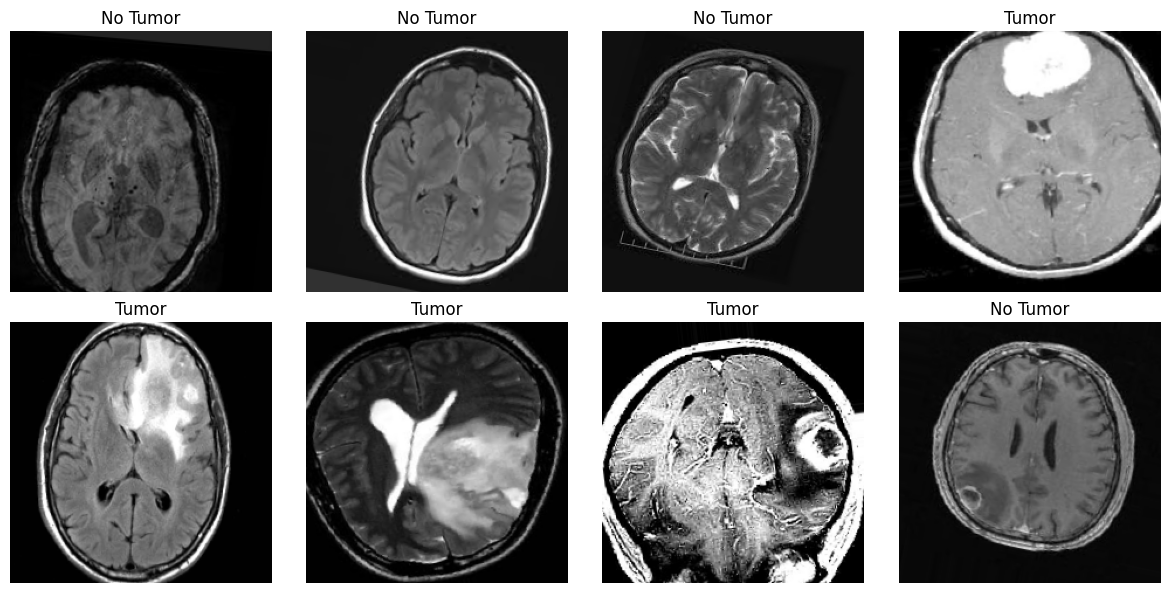

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    label = "Tumor" if labels[i] == 1 else "No Tumor"
    plt.title(label)
    plt.axis('off')
plt.tight_layout()
plt.show()

# flow_from_directory generators are stateful iterators — reset so training starts from batch 0
train_generator.reset()

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy', save_best_only=True
    )
]

In [ ]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6932 - loss: 1.7146 

26/26 ━━━━━━━━━━━━━━━━━━━━ 333s 13s/step - accuracy: 0.7519 - loss: 1.1220 - val_accuracy: 0.5600 - val_loss: 0.8336 - learning_rate: 1.0000e-04
Epoch 2/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.8025 - loss: 0.4196

26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 648ms/step - accuracy: 0.8105 - loss: 0.4071 - val_accuracy: 0.6750 - val_loss: 0.6521 - learning_rate: 1.0000e-04
Epoch 3/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 701ms/step - accuracy: 0.8354 - loss: 0.3767 - val_accuracy: 0.6550 - val_loss: 0.8270 - learning_rate: 1.0000e-04
Epoch 4/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 552ms/step - accuracy: 0.8292 - loss: 0.3825 - val_accuracy: 0.6400 - val_loss: 1.0635 - learning_rate: 1.0000e-04
Epoch 5/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 559ms/step - accuracy: 0.8579 - loss: 0.3500 - val_accuracy: 0.6150 - val_loss: 1.5431 - learning_rate: 1.0000e-04
Epoch 6/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 570ms/step - accuracy: 0.8566 - loss: 0.3247 - val_accuracy: 0.6000 - val_loss: 1.8018 - learning_rate: 5.0000e-05
Epoch 7/15
26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 564ms/step - accuracy: 0.8566 - loss: 0.3279 - val_accuracy: 0.6350 - val_loss: 1.9325 - learning_rate: 5.0000e-05


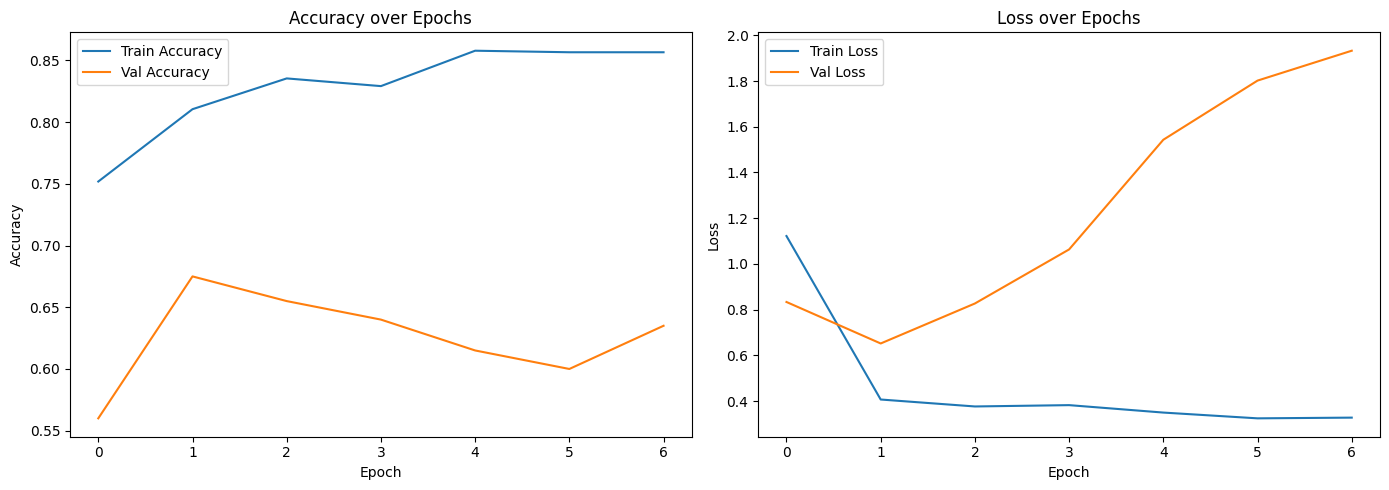

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.6750 - loss: 0.6521
Validation Loss: 0.6521 | Validation Accuracy: 0.6750
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step


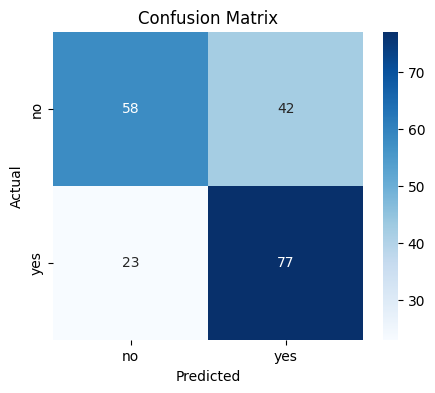

              precision    recall  f1-score   support

          no       0.72      0.58      0.64       100
         yes       0.65      0.77      0.70       100

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.67       200
weighted avg       0.68      0.68      0.67       200



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

val_generator.reset()
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}")

val_generator.reset()
y_true = val_generator.classes
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

class_labels = list(val_generator.class_indices.keys())  # ['no', 'yes']

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))

In [ ]:
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

# The line below saves in the modern Keras native format instead of legacy HDF5, if preferred:
# model.save(MODEL_PATH.replace('.h5', '.keras'))

Model saved to: /content/drive/MyDrive/Comptia_LAB/Brain_Tumor_Detection/BrainTumor.h5


Model Loaded
Testing on: /content/drive/MyDrive/Comptia_LAB/Brain_Tumor_Detection/data/pred/pred0.jpg


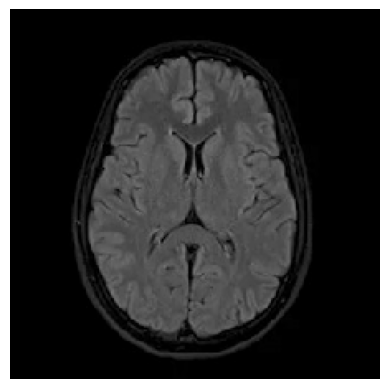

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 979ms/step
Raw prediction score: [[0.18334535]]
Prediction: No tumor detected (confidence: 81.67%)


In [ ]:
model = load_model(MODEL_PATH)
print("Model Loaded")

# Pick the first image found in the pred/ folder
pred_files = [f for f in os.listdir(PRED_DIR)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
test_image_path = os.path.join(PRED_DIR, pred_files[0])
print("Testing on:", test_image_path)

img = image.load_img(test_image_path, target_size=(IMG_SIZE, IMG_SIZE))
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.

prediction = model.predict(img_array)
print("Raw prediction score:", prediction)

if prediction[0][0] >= 0.5:
    print(f"Prediction: Tumor detected (confidence: {prediction[0][0]:.2%})")
else:
    print(f"Prediction: No tumor detected (confidence: {1 - prediction[0][0]:.2%})")